# DSA 8301 — Statistical Inference for Big Data
## Kenya Housing Survey 2023/24 · Housing Financial Vulnerability Score (HFVS)
### Data Cleaning & Preparation — Definitive Notebook

| | |
|---|---|
| **Student** | Valerie Jerono |
| **Reg. No.** | 222331 |
| **Supervisor** | Prof. Jacob Ong'ala |
| **Institution** | Strathmore University — iLabAfrica |
| **Date** | June 2026 |

---

### What this notebook does

Takes `master_frame.parquet` — **21,347 households × 443 columns** assembled from 14 KHS source
files — and produces a principled, analysis-ready working frame. Every cleaning decision is
domain-informed, documented, and reproducible.

**Pipeline (in order):**

| Stage | Action |
|-------|--------|
| 0 | Environment setup · paths · county map |
| 1 | Column rename (KNBS codes → semantic names) |
| 2 | KNBS sentinel-code decoding (−1, 96/98/99, 996/998/999 → NaN) |
| 3 | Full column audit (missingness · cardinality · module) |
| 4 | Stage-1 structural drops (free-text · admin · constants · >90% missing) |
| 5 | Multi-select pruning (sparse <0.5% "other" sub-items only) |
| 6 | Structural missingness encoding (k_ · l_ · lp_ · mort_) |
| 7 | Tenure-stratified imputation (Low ≤25%: impute; Moderate 25–40%: impute+flag; High >40%: leave NaN) |
| 8 | KES outlier treatment (Winsorise at p1/p99 of non-zero values) |
| 9 | Consistency checks & logical-contradiction flags |
| 10 | Feature engineering (total_exp · rent_burden · persons_per_room · obj_quality_score · triple_exposed · util_burden) |
| 11 | Pillar map integrity check + anti-leakage assertion |
| 12 | Save cleaned frame + preprocessing audit tables |

> **Dataset source:** Kenya National Bureau of Statistics (KNBS) — Kenya Housing Survey 2023/24,
> accessed via the iLabAfrica research portal. 21,347 households, 443 raw columns across
> administrative, dwelling, individual, land parcel, and contextual sub-files.


## 0 · Environment Setup

In [73]:
# ── 0.1  Mount Google Drive (Colab) or fall back to local CWD ──────────────
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
    print('Running in Google Colab — Drive mounted.')
except Exception:
    IN_COLAB = False
    print('Running locally — using current working directory.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Running in Google Colab — Drive mounted.


In [74]:
# ── 0.2  Install dependencies (Colab first-run; skips gracefully if present) ──
# pyarrow: Parquet I/O   scipy: statistics   statsmodels: regression
import subprocess, sys
subprocess.run(
    [sys.executable, '-m', 'pip', 'install', '-q', 'pyarrow', 'scipy', 'statsmodels'],
    check=False
)

CompletedProcess(args=['/usr/bin/python3', '-m', 'pip', 'install', '-q', 'pyarrow', 'scipy', 'statsmodels'], returncode=0)

In [75]:
# ── 0.3  Core imports ────────────────────────────────────────────────────────
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from pathlib import Path

warnings.filterwarnings('ignore')
np.random.seed(8301)

pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 60)
pd.set_option('display.max_rows', 80)

# ── Plotting theme ────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 130, 'figure.facecolor': 'white',
    'axes.facecolor': '#F8F8F6', 'axes.spines.top': False,
    'axes.spines.right': False, 'axes.titlesize': 13,
    'axes.titleweight': '600', 'axes.labelsize': 11,
    'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'font.family': 'sans-serif', 'legend.fontsize': 9,
})
TEAL   = '#00695C'; RED    = '#B71C1C'; AMBER  = '#E65100'
BLUE   = '#1565C0'; PURPLE = '#6A1B9A'; GRAY   = '#546E7A'

print('Imports loaded. NumPy', np.__version__, '| Pandas', pd.__version__)

Imports loaded. NumPy 2.0.2 | Pandas 2.2.2


In [76]:
# ── 0.4  Paths ───────────────────────────────────────────────────────────────
DRIVE = Path('/content/drive/MyDrive/KHS_Dissertation') if IN_COLAB else Path.cwd()
PQ    = DRIVE / 'data' / 'parquet'
FIGS  = DRIVE / 'outputs' / 'figures' / 'dsa8301_clean'
TABS  = DRIVE / 'outputs' / 'tables'  / 'dsa8301_clean'
for p in [FIGS, TABS]:
    p.mkdir(parents=True, exist_ok=True)
print(f'BASE → {DRIVE}')
print(f'PQ   → {PQ}')

BASE → /content/drive/MyDrive/KHS_Dissertation
PQ   → /content/drive/MyDrive/KHS_Dissertation/data/parquet


In [77]:
# ── 0.5  County map (KNBS: 1–47) ─────────────────────────────────────────────
COUNTY_MAP = {
     1:'Mombasa',        2:'Kwale',          3:'Kilifi',         4:'Tana River',
     5:'Lamu',           6:'Taita-Taveta',   7:'Garissa',        8:'Wajir',
     9:'Mandera',       10:'Marsabit',      11:'Isiolo',        12:'Meru',
    13:'Tharaka-Nithi', 14:'Embu',          15:'Kitui',         16:'Machakos',
    17:'Makueni',       18:'Nyandarua',     19:'Nyeri',         20:'Kirinyaga',
    21:"Murang'a",      22:'Kiambu',        23:'Turkana',       24:'West Pokot',
    25:'Samburu',       26:'Trans Nzoia',   27:'Uasin Gishu',   28:'Elgeyo-Marakwet',
    29:'Nandi',         30:'Baringo',       31:'Laikipia',      32:'Nakuru',
    33:'Narok',         34:'Kajiado',       35:'Kericho',       36:'Bomet',
    37:'Kakamega',      38:'Vihiga',        39:'Bungoma',       40:'Busia',
    41:'Siaya',         42:'Kisumu',        43:'Homa Bay',      44:'Migori',
    45:'Kisii',         46:'Nyamira',       47:'Nairobi',
}
print(f'County map loaded: {len(COUNTY_MAP)} counties.')

County map loaded: 47 counties.


## 1 · Column Rename Map (KNBS codes → semantic names)

Applied **before** sentinel decoding so all subsequent code works with readable names.
Only columns actually present in the frame are renamed — the rest are silently skipped.


In [78]:
# ── 1.1  Full rename map ─────────────────────────────────────────────────────
RENAME_MAP = {
    # Admin / geo / weights
    'interview__key': 'hh_id',        'interview__id': 'hh_uuid',
    'a01':   'county_code',           'countycode':    'county_code_str',
    'a07_1': 'urban_rural',           'serial':        'hh_serial',
    'hhweight': 'hh_weight',          'a12':           'interview_result',
    'tag':   'survey_tag',            'rnd':           'sample_round',
    'selectedage': 'selected_respondent_age',

    # Water & sanitation
    'c01_1': 'water_src_main',        'c01_2': 'water_collect_method',
    'c01_3': 'water_treated',         'c01_4': 'water_dist_mins',
    'c01_5': 'water_src_main_season', 'c02_1': 'water_src_secondary',
    'c02_2': 'water_collect_secondary','c02_3': 'water_secondary_treated',
    'c02_4': 'water_secondary_dist_mins','c02_5': 'water_secondary_season',
    'c03':   'n_toilet_facilities',   'c04':   'toilet_type',
    'c05':   'has_handwash_facility', 'c06':   'n_hh_sharing_toilet',
    'c07':   'handwash_materials',    'c08':   'has_bathhouse',
    'c14_1': 'spend_water_kes',

    # Energy
    'c10':   'lighting_src',          'c10_2': 'electricity_hrs_day',
    'c10_3': 'electricity_supply_type','c10_4': 'electricity_conn_type',
    'c11':   'cooking_fuel',          'c11_1': 'cooking_fuel_n_types',
    'c11_2': 'cooking_fuel_secondary','c12':   'cooking_stove_type',
    'c12_1': 'n_cooking_spaces',      'c12_2': 'cooking_space_indoor',
    'c14_2': 'spend_electricity_kes', 'c14_3': 'spend_energy_other_kes',

    # Assets
    'c13__1': 'owns_radio',  'c13__2': 'owns_mobile',  'c13__3': 'owns_tv',
    'c13__4': 'owns_computer','c13__5': 'owns_motorcycle','c13__6': 'owns_vehicle',
    'c13__7': 'owns_fridge', 'c13__96': 'owns_other_asset','internet': 'has_internet',

    # Waste collection (c09__)
    'c09__1': 'waste_coll_county',    'c09__2': 'waste_coll_private',
    'c09__3': 'waste_coll_ngo',       'c09__4': 'waste_coll_community',
    'c09__5': 'waste_coll_self',      'c09__6': 'waste_coll_neighbour',
    'c09__7': 'waste_coll_other',

    # Dwelling (household module)
    'd01':    'hh_tenure_type',       'd17':   'dwelling_ownership_doc',
    'd18__1': 'ownership_doc_title_deed', 'd18__8': 'ownership_doc_none',
    'd19':    'n_hh_in_building',
    'd20__1': 'shared_facility_water','d20__2': 'shared_facility_toilet',
    'd20__3': 'shared_facility_bathroom','d20__4': 'shared_facility_kitchen',
    'd20__5': 'shared_facility_entrance','d20__6': 'shared_facility_yard',
    'd20__7': 'shared_facility_parking','d20__8': 'shared_facility_none',
    'duration': 'tenancy_duration_cat','year_occ': 'year_occupied_cat',
    'bf':     'building_floor_cat',

    # Expenditure (g01a–k)
    'g01a': 'spend_food_kes',         'g01b': 'spend_clothing_kes',
    'g01c': 'spend_education_kes',    'g01d': 'spend_health_kes',
    'g01e': 'spend_transport_kes',    'g01f': 'spend_comms_kes',
    'g01g': 'spend_recreation_kes',   'g01h': 'spend_housing_kes',
    'g01i': 'spend_energy_kes',       'g01j': 'spend_other_kes',
    'g01k': 'spend_remittances_kes',
    'g02':  'pays_rent',              'g02_1': 'rent_monthly_kes',
    'g03':  'tenure_type',            'g04':   'owns_other_property',

    # Housing problems (g05)
    'g05__1': 'prob_overcrowding',    'g05__2': 'prob_poor_water',
    'g05__3': 'prob_poor_sanitation', 'g05__4': 'prob_poor_drainage',
    'g05__5': 'prob_poor_road',       'g05__6': 'prob_insecurity',
    'g05__7': 'prob_high_cost',       'g05__8': 'prob_poor_structure',
    'g05__9': 'prob_crime',           'g05__10': 'prob_other',

    # Housing aspirations (g06)
    'g06__1': 'aspire_buy_land',      'g06__2': 'aspire_build',
    'g06__3': 'aspire_buy_house',     'g06__4': 'aspire_rent_better',
    'g06__5': 'aspire_renovate',      'g06__6': 'aspire_move_county',
    'g06__7': 'aspire_stay_improve',  'g06__8': 'aspire_no_change',

    # Housing perception (h01–h11)
    'h01': 'perc_structure', 'h02': 'perc_roof',     'h03': 'perc_walls',
    'h04': 'perc_floor',     'h05': 'perc_ventilation','h06': 'perc_lighting',
    'h07': 'perc_water',     'h08': 'perc_sanitation','h09': 'perc_waste',
    'h10': 'perc_security',  'h11': 'perc_overall',

    # Land ownership
    'i00': 'owns_land',

    # Environment & hazards (e module)
    'e05': 'dist_to_market_mins',     'e06': 'flood_exposure',
    'e07': 'landslide_exposure',      'e08': 'other_hazard_exposure',
    'e09__1': 'hazard_lost_property', 'e09__2': 'hazard_injured',
    'e09__3': 'hazard_displaced',     'e09__4': 'hazard_death',
    'e09__5': 'hazard_none',

    # Tenure & mobility (j module)
    'j02':   'ever_owned_dwelling',   'j04_1': 'is_owner_occupier',
    'j04_2': 'tenure_is_informal',    'j05':   'has_title_doc',
    'j09':   'housing_cost_burden',   'j10':   'missed_payment',
    'j11':   'eviction_risk',         'j12_1': 'yrs_in_dwelling',
    'j13':   'satisfied_tenure',      'j14':   'wants_to_own',
    'j15':   'applied_for_housing',   'j17':   'willing_to_relocate',
    'j20':   'aware_affordable_housing','j21':  'applied_affordable_housing',

    # Rental module (k)
    'k01': 'rental_market_type',  'k02': 'has_written_lease',
    'k03': 'rent_negotiated',     'k04': 'landlord_type',
    'k05': 'rent_actual_kes',     'k09': 'lease_type',
    'k13': 'receipt_given',       'k15': 'has_rent_dispute',
    'k20': 'plans_to_buy',        'k21': 'rent_arrears',
    'k25': 'willingness_to_pay_kes',
    'min_rent': 'psu_min_rent_kes',

    # Owned dwelling (l module)
    'l07': 'dwelling_yr_surveyed', 'l08': 'dwelling_yr_built',
    'l13': 'dwelling_value_kes',   'l14': 'land_value_kes',
    'l15': 'mortgage_repayment_kes','l19': 'plot_size_decimals',
    'l21': 'had_renovation',       'l28': 'yr_last_renovated',

    # Derived / pre-computed
    'prop_util':  'util_income_ratio',  'med_prop':   'cty_med_util_ratio',
    'utilities':  'pays_utilities',     'ctymin_ut':  'cty_min_utility_kes',
    'med_brms':   'cty_med_bedrooms',   'sf':         'is_slum',
    'pln':        'settlement_plan_status',

    # Dwelling file aggregates
    'dw_type': 'dw_type',             'dw_wall_material': 'dw_wall_mat',
    'dw_roof_material': 'dw_roof_mat','dw_floor_material': 'dw_floor_mat',
    'dw_n_rooms': 'dw_rooms',         'dw_floor_area_m2': 'dw_area_m2',
    'dw_n_bedrooms': 'dw_bedrooms',   'dw_approved': 'dw_approved',
    'dw_planning_ok': 'dw_has_planning','dw_hazard_zone': 'dw_in_hazard_zone',
    'dw_n_units_enumerated': 'dw_units_count',

    # Individual aggregates
    'hh_size': 'hh_size',             'hhh_sex': 'hh_head_sex',
    'any_disability': 'has_disability','max_edu_isced': 'max_edu_isced',
    'mean_age': 'mean_age',            'dependency_ratio': 'dependency_ratio',
    'n_female': 'n_female',            'n_children': 'n_children',
    'n_elderly': 'n_elderly',          'n_working_age': 'n_working_age',

    # Land parcel aggregates (55% structural missing — landless households)
    'lp_n_parcels': 'lp_n_parcels',   'lp_primary_tenure': 'lp_tenure_type',
    'lp_has_title': 'lp_has_title',   'lp_primary_use': 'lp_land_use',
    'lp_any_dispute': 'lp_has_dispute','lp_any_registered': 'lp_is_registered',
    'lp_any_collateral': 'lp_used_as_collateral',

    # County / contextual aggregates
    'cty_housing_stock': 'cty_housing_stock',
    'cty_housing_backlog': 'cty_housing_backlog',
    'cty_has_housing_policy': 'cty_has_housing_policy',
    'cty_building_approval_system': 'cty_approval_system',

    # NEMA / water service / mortgage / loan / financier aggregates
    'nema_eia_applications': 'nema_eia_apps',
    'nema_eia_approvals': 'nema_eia_approvals',
    'nema_processing_days': 'nema_proc_days',
    'wsvc_water_connections': 'wsvc_water_conns',
    'wsvc_sewer_connections': 'wsvc_sewer_conns',
    'wsvc_water_tariff': 'wsvc_tariff',
    'wsvc_service_quality': 'wsvc_quality',
    'mort_interest_rate': 'mort_rate',   'mort_ltv_ratio': 'mort_ltv',
    'mort_avg_term_years': 'mort_term_yrs','mort_n_providers': 'mort_n_providers',
    'loan_avg_size': 'loan_avg_kes',     'loan_outstanding': 'loan_outstanding_kes',
    'loan_n_providers': 'loan_n_providers',
    'fin_portfolio': 'fin_portfolio_kes','fin_n_financiers': 'fin_n_financiers',
}
INVERSE_MAP = {v: k for k, v in RENAME_MAP.items()}
print(f'RENAME_MAP: {len(RENAME_MAP)} entries defined.')

RENAME_MAP: 215 entries defined.


## 2 · Load & Rename

In [79]:
# ── 2.1  Load master_frame.parquet ───────────────────────────────────────────
candidates = [
    PQ / 'master_frame.parquet',
    Path('master_frame.parquet'),
    Path('/content/master_frame.parquet'),
]
DATA_PATH = next((p for p in candidates if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError(
        'Cannot find master_frame.parquet. '
        'Place it in data/parquet/, the CWD, or /content/.'
    )
df = pd.read_parquet(DATA_PATH)
print(f'Loaded   → {DATA_PATH}')
print(f'Shape    → {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Memory   → {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')
print()
# Identity check: no fully duplicated rows before anything else
n_dupe = df.duplicated().sum()
print(f'Fully duplicated rows: {n_dupe}  (must be 0 to proceed)')
assert n_dupe == 0, 'Duplicated rows found — resolve in master frame build.'

Loaded   → /content/drive/MyDrive/KHS_Dissertation/data/parquet/master_frame.parquet
Shape    → 21,347 rows × 443 columns
Memory   → 107.0 MB

Fully duplicated rows: 0  (must be 0 to proceed)


In [80]:
# ── 2.2  Apply rename map (defensive: only renames columns that exist) ────────
rename_now = {raw: sem for raw, sem in RENAME_MAP.items() if raw in df.columns}
df = df.rename(columns=rename_now)
print(f'Renamed {len(rename_now)} columns.')
print(f'Shape unchanged: {df.shape}')
print()
print('Sample — first 8 columns after rename:')
print(df.columns[:8].tolist())

Renamed 215 columns.
Shape unchanged: (21347, 443)

Sample — first 8 columns after rename:
['hh_id', 'hh_uuid', 'county_code', 'county_code_str', 'urban_rural', 'hh_serial', 'interview_result', 'water_src_main']


## 3 · KNBS Sentinel-Code Decoding

KNBS SurveySolutions uses several numeric sentinel codes that must be decoded to
`NaN` **before** any statistics, imputation, or outlier analysis.

| Code(s) | Meaning |
|---------|---------|
| `−1` | Not applicable / routing skip |
| `96` / `996` | Other (open-ended) |
| `98` / `998` | Don't know |
| `99` / `999` | Refused / missing |

**Protected columns** (where these numbers are valid data) are excluded:
county code, survey weights, binary 0/1 indicators.


In [81]:
# ── 3.1  Protected columns — sentinel decoding is skipped for these ──────────
PROTECTED_FROM_SENTINEL = {
    'county_code', 'hh_weight', 'urban_rural', 'hh_id',
    # Binary 0/1 indicators where 0 and 1 are real values
    'owns_radio', 'owns_mobile', 'owns_tv', 'owns_computer',
    'owns_motorcycle', 'owns_vehicle', 'owns_fridge', 'has_internet',
    'prob_overcrowding', 'prob_poor_water', 'prob_poor_sanitation',
    'prob_poor_drainage', 'prob_poor_road', 'prob_insecurity',
    'prob_high_cost', 'prob_poor_structure', 'prob_crime',
    'aspire_buy_land', 'aspire_build', 'aspire_buy_house',
    'aspire_rent_better', 'aspire_renovate', 'aspire_move_county',
    'aspire_stay_improve', 'aspire_no_change',
    'ownership_doc_title_deed', 'ownership_doc_none',
    'shared_facility_water', 'shared_facility_toilet',
    'shared_facility_bathroom', 'shared_facility_kitchen',
    'shared_facility_entrance', 'shared_facility_yard',
    'shared_facility_parking', 'shared_facility_none',
    'waste_coll_county', 'waste_coll_private', 'waste_coll_ngo',
    'waste_coll_community', 'waste_coll_self', 'waste_coll_neighbour',
    'dw_approved', 'dw_has_planning', 'dw_in_hazard_zone',
    'has_disability', 'lp_has_title', 'lp_has_dispute',
    'lp_is_registered', 'lp_used_as_collateral', 'cty_has_housing_policy',
}
print(f'Protected columns (sentinel-safe): {len(PROTECTED_FROM_SENTINEL)}')

Protected columns (sentinel-safe): 54


In [82]:
# ── 3.2  Decode sentinels to NaN ─────────────────────────────────────────────
SENTINELS = {-1, 96, 98, 99, 996, 997, 998, 999}

sentinel_log = []
for c in df.select_dtypes(include='number').columns:
    if c in PROTECTED_FROM_SENTINEL:
        continue
    mask = df[c].isin(SENTINELS)
    n = mask.sum()
    if n > 0:
        df.loc[mask, c] = np.nan
        sentinel_log.append({'column': c, 'n_decoded': n})

sentinel_df = pd.DataFrame(sentinel_log).sort_values('n_decoded', ascending=False)
sentinel_df.to_csv(TABS / '01_sentinel_decoding_log.csv', index=False)
print(f'Columns with sentinel values decoded: {len(sentinel_df)}')
print(f'Total cells set to NaN             : {sentinel_df["n_decoded"].sum():,}')
print()
print('Top 15 columns by cells decoded:')
print(sentinel_df.head(15).to_string(index=False))

Columns with sentinel values decoded: 48
Total cells set to NaN             : 23,626

Top 15 columns by cells decoded:
                column  n_decoded
     yr_last_renovated       9507
   electricity_hrs_day       4714
spend_energy_other_kes       1819
 spend_electricity_kes       1251
       yrs_in_dwelling        783
                 j12_2        757
                 c11_3        616
         nema_eia_apps        573
       spend_water_kes        482
    nema_eia_approvals        480
   cty_approval_system        455
   n_toilet_facilities        441
   cty_housing_backlog        420
   water_src_secondary        163
                   e03        163


## 4 · Column Audit

A full inventory of all 443 columns: dtype, missingness %, cardinality, and
questionnaire module. This runs **after** sentinel decoding so missingness
percentages reflect true data absence, not embedded sentinel codes.


In [83]:
# ── 4.1  Module classifier ───────────────────────────────────────────────────
MODULE_LABELS = {
    'a': 'admin_geo',           'b': 'individual_raw',
    'c': 'water_energy_assets', 'd': 'dwelling_hh_module',
    'e': 'environment_hazards', 'g': 'income_expenditure',
    'h': 'housing_perception',  'i': 'land_ownership',
    'j': 'tenure_mobility',     'k': 'rental_module',
    'l': 'owned_dwelling',
}

def get_module(col_name):
    orig = INVERSE_MAP.get(col_name, col_name)
    m = re.match(r'^([a-z]+)\d', orig)
    if m:
        return MODULE_LABELS.get(m.group(1), 'derived_aggregate')
    return 'derived_aggregate'

def dominant_pct(s):
    vc = s.value_counts(normalize=True, dropna=True)
    return round(float(vc.iloc[0]) * 100, 2) if len(vc) else np.nan

# Build full inventory
audit_rows = []
for c in df.columns:
    s = df[c]
    pct_miss = s.isna().mean() * 100
    audit_rows.append({
        'column':       c,
        'module':       get_module(c),
        'dtype':        str(s.dtype),
        'pct_missing':  round(pct_miss, 2),
        'n_unique':     s.nunique(dropna=True),
        'dominant_pct': dominant_pct(s),
    })

audit = pd.DataFrame(audit_rows).set_index('column')

def miss_tier(p):
    if p == 0:   return '0_Complete'
    if p <= 20:  return '1_Low'
    if p <= 60:  return '2_Moderate'
    return               '3_High'

audit['miss_tier'] = audit['pct_missing'].apply(miss_tier)
audit.to_csv(TABS / '02_full_column_audit.csv')

print('=== Column audit complete ===')
print(f'Total columns: {len(audit)}')
print()
print('By module:')
print(audit['module'].value_counts().to_string())
print()
print('By missingness tier:')
print(audit['miss_tier'].value_counts().sort_index().to_string())
print()
print(f'Constant columns (n_unique ≤ 1): {(audit["n_unique"] <= 1).sum()}')

=== Column audit complete ===
Total columns: 443

By module:
module
owned_dwelling         81
water_energy_assets    71
derived_aggregate      71
rental_module          63
tenure_mobility        53
income_expenditure     35
environment_hazards    33
dwelling_hh_module     21
housing_perception     11
admin_geo               3
land_ownership          1

By missingness tier:
miss_tier
0_Complete     73
1_Low         135
2_Moderate     67
3_High        168

Constant columns (n_unique ≤ 1): 4


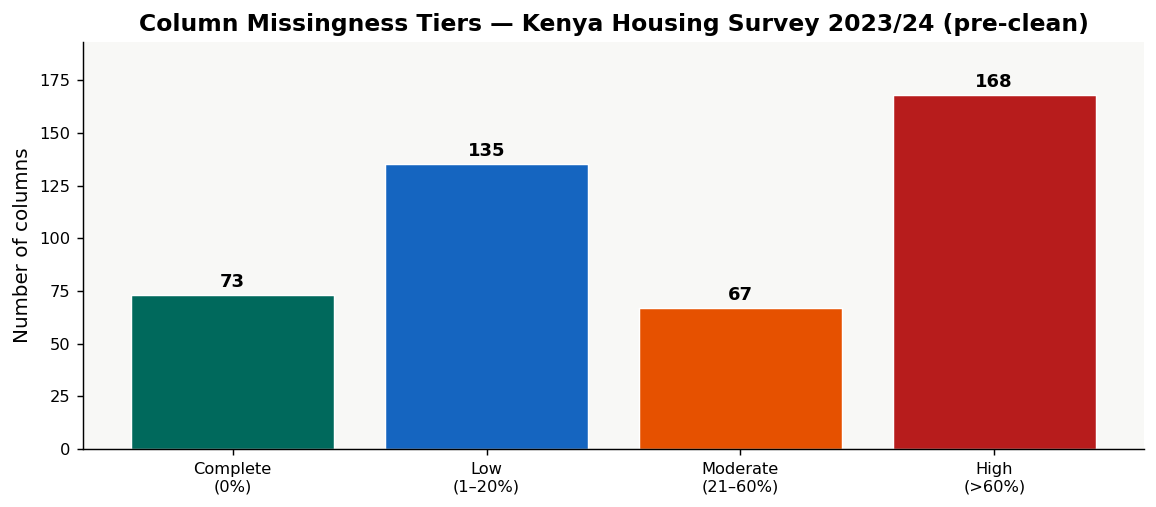

Figure saved.


In [48]:
# ── 4.2  Missingness overview plot ───────────────────────────────────────────
tier_counts = audit['miss_tier'].value_counts().sort_index()
labels = ['Complete\n(0%)', 'Low\n(1–20%)', 'Moderate\n(21–60%)', 'High\n(>60%)']
colours = [TEAL, BLUE, AMBER, RED]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(labels, tier_counts.values, color=colours, edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, tier_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            str(val), ha='center', va='bottom', fontsize=10, fontweight='600')
ax.set_title('Column Missingness Tiers — Kenya Housing Survey 2023/24 (pre-clean)')
ax.set_ylabel('Number of columns')
ax.set_ylim(0, tier_counts.max() * 1.15)
fig.tight_layout()
fig.savefig(FIGS / '01_missingness_tier_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')

## 5 · Stage-1 Structural Drops

Four categories of columns are dropped before any analysis. A **core-keep set**
protects all HFVS pillar ingredients, proxy features, and derived aggregates
from being auto-dropped regardless of their missingness profile.

| Drop category | Rationale |
|---|---|
| Free-text "other/specify" fields | Open strings; not codeable |
| Admin / survey-logistics identifiers | Non-analytical duplicates |
| Constant columns (≤1 unique value) | Zero information |
| Near-empty (>90% missing, non-structural) | Too sparse to use |

> **Why 90%, not 80%?** KHS routing means k_/l_/lp_ columns can legitimately be
> 55–68% missing for the *correct* subpopulation. Using 90% as the threshold
> avoids accidentally discarding valid but module-specific variables.


In [49]:
# ── 5.1  Explicit keep set — only columns with a defined role survive ─────────
FINAL_KEEP = {
    # ── Identity / geo / weight ───────────────────────────────────────────────
    'hh_id', 'county_code', 'urban_rural', 'hh_weight',

    # ── Pillar 1: Financial Stress ────────────────────────────────────────────
    'spend_food_kes', 'spend_clothing_kes', 'spend_education_kes',
    'spend_health_kes', 'spend_transport_kes', 'spend_comms_kes',
    'spend_recreation_kes', 'spend_housing_kes', 'spend_energy_kes',
    'spend_other_kes', 'spend_remittances_kes',
    'pays_rent', 'rent_monthly_kes', 'rent_actual_kes',
    'mortgage_repayment_kes', 'housing_cost_burden', 'missed_payment',

    # ── Pillar 2: Dwelling Quality ────────────────────────────────────────────
    'dw_type', 'dw_wall_mat', 'dw_roof_mat', 'dw_floor_mat',
    'dw_rooms', 'dw_bedrooms', 'dw_area_m2', 'dw_approved', 'dw_has_planning',
    'perc_structure', 'perc_roof', 'perc_walls', 'perc_floor',
    'perc_ventilation', 'perc_lighting', 'perc_water', 'perc_sanitation',
    'perc_waste', 'perc_security', 'perc_overall',
    'had_renovation', 'dwelling_yr_built',

    # ── Pillar 3: Tenure Insecurity ───────────────────────────────────────────
    'tenure_type', 'hh_tenure_type', 'is_owner_occupier', 'tenure_is_informal',
    'has_title_doc', 'owns_land', 'owns_other_property',
    'eviction_risk', 'yrs_in_dwelling', 'satisfied_tenure',
    'tenancy_duration_cat', 'year_occupied_cat',
    'has_written_lease', 'lease_type', 'rent_arrears', 'rent_negotiated',
    'plans_to_buy', 'psu_min_rent_kes', 'rental_market_type',
    'dwelling_value_kes', 'plot_size_decimals',
    'lp_n_parcels', 'lp_tenure_type', 'lp_has_title', 'lp_land_use',
    'lp_has_dispute', 'lp_is_registered', 'lp_used_as_collateral',

    # ── Pillar 4: Physical Hazard ─────────────────────────────────────────────
    'flood_exposure', 'landslide_exposure', 'other_hazard_exposure',
    'dw_in_hazard_zone', 'hazard_lost_property', 'hazard_displaced',
    'dist_to_market_mins',
    'prob_overcrowding', 'prob_poor_water', 'prob_poor_sanitation',
    'prob_poor_drainage', 'prob_insecurity', 'prob_high_cost', 'prob_poor_structure',

    # ── Pillar 5: Utility Deprivation ─────────────────────────────────────────
    'water_src_main', 'water_collect_method', 'water_treated', 'water_dist_mins',
    'spend_water_kes', 'has_handwash_facility',
    'toilet_type',
    'lighting_src', 'electricity_hrs_day', 'electricity_conn_type',
    'cooking_fuel', 'cooking_stove_type',
    'spend_electricity_kes', 'spend_energy_other_kes',
    'util_income_ratio', 'pays_utilities',
    'cty_min_utility_kes', 'cty_med_util_ratio',

    # ── Household demographics ────────────────────────────────────────────────
    'hh_size', 'hh_head_sex', 'has_disability', 'max_edu_isced',
    'mean_age', 'dependency_ratio', 'n_female', 'n_children', 'n_elderly',

    # ── Contextual / county-level ─────────────────────────────────────────────
    'cty_med_bedrooms', 'is_slum', 'settlement_plan_status',

    # ── Proxy / aspiration features ───────────────────────────────────────────
    'owns_radio', 'owns_mobile', 'owns_tv', 'owns_computer',
    'owns_motorcycle', 'owns_vehicle', 'owns_fridge', 'has_internet',
    'aspire_buy_land', 'aspire_build', 'aspire_buy_house',
    'wants_to_own', 'willing_to_relocate', 'aware_affordable_housing',
}

CORE_KEEP = FINAL_KEEP & set(df.columns)
print(f'Columns to keep: {len(CORE_KEEP)}')
missing_from_df = FINAL_KEEP - set(df.columns)
if missing_from_df:
    print(f'Defined but not in df ({len(missing_from_df)}): {sorted(missing_from_df)}')

Columns to keep: 129


In [50]:
# ── 5.2  Drop only what is definitively useless ───────────────────────────────

FREE_TEXT_RX = re.compile(
    r'(other_text|other_specify|_other\d*$|_other$|_text$|_specify$)', re.I
)
free_text_cols = [c for c in df.columns
                  if FREE_TEXT_RX.search(c) and c not in CORE_KEEP]

admin_drop = [c for c in [
    'survey_tag', 'sample_round', 'selected_respondent_age',
    'county_code_str', 'hh_serial', 'interview_result', 'hh_uuid',
    'dwelling_yr_surveyed', 'yr_last_renovated',          # admin dates, not analytical
    'dw_units_count', 'building_floor_cat', 'n_hh_in_building',  # structural noise
] if c in df.columns]

constant_cols = [c for c in df.columns
                 if df[c].nunique(dropna=True) <= 1 and c not in CORE_KEEP]

# Near-empty only for columns outside CORE_KEEP AND with random (uninformed) missingness.
# Structurally-missing columns (lp_*, rental, owned-dwelling modules) are protected by CORE_KEEP.
NEAR_EMPTY_THRESHOLD = 90.0
near_empty_cols = audit.index[
    (audit['pct_missing'] > NEAR_EMPTY_THRESHOLD) & (~audit.index.isin(CORE_KEEP))
].tolist()

stage1_drop = sorted(set(free_text_cols + admin_drop + constant_cols + near_empty_cols))

print(f'Free-text / specify fields : {len(free_text_cols)}')
print(f'Admin / noise columns      : {len(admin_drop)}')
print(f'Constant columns           : {len(constant_cols)}')
print(f'Near-empty (>90% missing)  : {len(near_empty_cols)}')
print(f'TOTAL stage-1 drops        : {len(stage1_drop)}')
print(f'\nDropping: {stage1_drop}')

df = df.drop(columns=stage1_drop)
audit = audit.loc[audit.index.isin(df.columns)]
print(f'\nShape after stage-1 drops: {df.shape[0]:,} rows × {df.shape[1]} columns')

Free-text / specify fields : 11
Admin / noise columns      : 12
Constant columns           : 3
Near-empty (>90% missing)  : 63
TOTAL stage-1 drops        : 87

Dropping: ['applied_affordable_housing', 'applied_for_housing', 'building_floor_cat', 'c03_other', 'c09_other', 'c11_other', 'c12_other', 'c13_other', 'county_code_str', 'dw_units_count', 'dwelling_yr_surveyed', 'hh_serial', 'hh_uuid', 'interview_result', 'j06_2_other', 'j16__1', 'j16__2', 'j16__3', 'j16__4', 'j16__5', 'j16__6', 'j16__96', 'j18', 'j19__1', 'j19__2', 'j19__3', 'j19__4', 'j19__5', 'j19__6', 'j19__96', 'j22__1', 'j22__2', 'j22__3', 'j22__4', 'j22__5', 'j22__96', 'k08_2', 'k08_3', 'k10', 'k14', 'k16', 'k17', 'k18', 'k19', 'k19_1', 'k24_1', 'k26__96', 'k26_other', 'k27', 'k28', 'k30', 'k31', 'k32', 'k33_other', 'k36', 'k38', 'k39', 'k39_other', 'l02__1', 'l02__2', 'l02__3', 'l02__4', 'l02__5', 'l02__6', 'l02__7', 'l02__8', 'l02__96', 'l09', 'l10', 'l11', 'l12', 'l24', 'l27__1', 'l27__2', 'l27__3', 'l27__4', 'l27__5',

## 6 · Multi-Select Indicator Pruning

Multi-select ("tick all that apply") questions produce a separate binary column
per option. Sparse "other" residual options selected by fewer than 0.5% of
households carry no analytical weight and are pruned here. **Substantive
indicators — even rare ones — are retained; rarity is itself informative.**


In [51]:
# ── 6.1  Prune sparse multi-select sub-items (<0.5% selection rate) ─────────
multiselect_groups = {}
for c in df.columns:
    orig = INVERSE_MAP.get(c, '')
    m = re.match(r'^([a-z0-9]+)__\d+', orig)
    if m:
        multiselect_groups.setdefault(m.group(1), []).append(c)

ms_prune = []
for grp, cols in multiselect_groups.items():
    for c in cols:
        if c in CORE_KEEP:
            continue
        rate = df[c].mean(skipna=True)
        if pd.notna(rate) and rate < 0.005:
            ms_prune.append((grp, c, round(rate * 100, 3)))

ms_prune_df = pd.DataFrame(ms_prune, columns=['group', 'column', 'selected_pct'])
print(f'Multi-select groups found: {len(multiselect_groups)}')
print(f'Sparse sub-items pruned (<0.5%): {len(ms_prune_df)}')
if len(ms_prune_df):
    print(ms_prune_df.to_string(index=False))

df = df.drop(columns=ms_prune_df['column'].tolist())
audit = audit.loc[audit.index.isin(df.columns)]
print(f'\nShape after multi-select pruning: {df.shape}')

Multi-select groups found: 7
Sparse sub-items pruned (<0.5%): 1
group           column  selected_pct
  c13 owns_other_asset        0.0880

Shape after multi-select pruning: (21347, 355)


## 7 · Structural Missingness Encoding

Three blocks of KHS columns have high missingness that is **not random** — it
encodes "not applicable" for households correctly routed away from that module.

| Block | Approx miss% | Root cause |
|-------|-------------|------------|
| Rental `k_*` | ~68% | Only asked of tenant households |
| Owned `l_*` | ~55% | Only asked of owner-occupier households |
| Land parcel `lp_*` | ~55% | Only asked where `owns_land == 1` |
| Mortgage `mort_rate` | ~81% | Counties with no formal mortgage market |

**Treatment rules:**
- Categorical / ordinal k_/l_ columns → recode NaN to **−1** ("Not applicable")
- Continuous KES columns in k_/l_ → **leave as NaN** (excluded per subpopulation in analysis)
- `lp_*` binary/count columns where `owns_land == 0` → **zero** (no land = zero parcel count)
- `mort_rate` NaN → encode a binary `mort_no_market` flag; rate itself stays NaN


In [52]:
# ── 7.1  Tenure flags ────────────────────────────────────────────────────────
if 'pays_rent' in df.columns:
    df['is_renter'] = df['pays_rent'].eq(1).astype(int)
    print(f'is_renter=1: {df["is_renter"].sum():,} ({df["is_renter"].mean():.1%})')
if 'tenure_type' in df.columns:
    df['is_owner'] = df['tenure_type'].eq(1).astype(int)
    print(f'is_owner=1 : {df["is_owner"].sum():,} ({df["is_owner"].mean():.1%})')
if {'is_renter', 'is_owner'}.issubset(df.columns):
    n_other = ((df['is_renter'] == 0) & (df['is_owner'] == 0)).sum()
    print(f'Neither    : {n_other:,} ({n_other/len(df):.1%})  — employer-provided / informal')

is_renter=1: 4,673 (21.9%)
is_owner=1 : 2,002 (9.4%)
Neither    : 14,905 (69.8%)  — employer-provided / informal


In [53]:
# ── 7.2  Recode k_* / l_* structural NaN → -1 (Not applicable) ──────────────
KES_CONTINUOUS = {
    'rent_actual_kes', 'rent_monthly_kes', 'psu_min_rent_kes',
    'dwelling_value_kes', 'land_value_kes', 'mortgage_repayment_kes',
    'willingness_to_pay_kes',
}

def get_module_prefix(col):
    orig = INVERSE_MAP.get(col, col)
    m = re.match(r'^([a-z]+)', orig)
    return m.group(1) if m else ''

struct_log = []
for c in df.columns:
    pfx = get_module_prefix(c)
    if pfx not in ('k', 'l'):
        continue
    if c in KES_CONTINUOUS:
        continue
    n_miss = df[c].isna().sum()
    if n_miss == 0:
        continue
    if pd.api.types.is_numeric_dtype(df[c]) and df[c].dropna().nunique() <= 15:
        df[c] = df[c].fillna(-1)
        struct_log.append({'column': c, 'treatment': 'recode_minus1', 'n_cells': n_miss})
    else:
        struct_log.append({'column': c, 'treatment': 'left_NaN_continuous', 'n_cells': n_miss})

struct_df = pd.DataFrame(struct_log)
print(f'k_/l_ structural treatments: {len(struct_df)}')
print(struct_df.groupby('treatment')['n_cells'].agg(['count', 'sum']).to_string())

k_/l_ structural treatments: 78
                     count      sum
treatment                          
left_NaN_continuous      7    88384
recode_minus1           71  1045212


In [54]:
# ── 7.3  Land parcel (lp_*) — landless households → 0 or -1 ─────────────────
# For owns_land == 0: binary/count lp_ columns = 0 (no parcels); categorical = -1
LP_BINARY = [c for c in df.columns if c.startswith('lp_')
             and c not in ('lp_n_parcels', 'lp_land_use', 'lp_tenure_type')]
LP_COUNT   = ['lp_n_parcels']
LP_CAT     = ['lp_land_use', 'lp_tenure_type']

if 'owns_land' in df.columns:
    landless = df['owns_land'].eq(0)
    for c in LP_BINARY:
        if c in df.columns:
            df.loc[landless, c] = df.loc[landless, c].fillna(0)
    for c in LP_COUNT:
        if c in df.columns:
            df.loc[landless, c] = df.loc[landless, c].fillna(0)
    for c in LP_CAT:
        if c in df.columns:
            df.loc[landless, c] = df.loc[landless, c].fillna(-1)
    print(f'Landless households (owns_land=0): {landless.sum():,}')
    print(f'lp_* binary/count columns zero-filled: {len(LP_BINARY + LP_COUNT)}')

# ── 7.4  Mortgage rate: no formal market flag ──────────────────────────────────
if 'mort_rate' in df.columns:
    df['mort_no_market'] = df['mort_rate'].isna().astype(int)
    n_no = df['mort_no_market'].sum()
    print(f'\nmort_no_market=1 (no formal mortgage): {n_no:,} ({n_no/len(df):.1%})')

Landless households (owns_land=0): 11,639
lp_* binary/count columns zero-filled: 5

mort_no_market=1 (no formal mortgage): 17,204 (80.6%)


## 8 · Group-Stratified Imputation

Residual missing values (after structural encoding) are imputed within three
tenure strata — owner, renter, other — so the imputed value reflects the
household's actual housing context.

| Miss% tier | Treatment |
|-----------|-----------|
| Low (0–25%) | Group-mode (categorical) or group-median (continuous) |
| Moderate (25–40%) | Same, plus a `_imputed` flag column |
| High (>40%) | **Left as NaN** — imputed value would be more assumption than data |

KES monetary columns and pre-computed county aggregates are excluded from
imputation entirely (their NaN has domain meaning).


In [55]:
# ── 8.1  Tenure stratification ───────────────────────────────────────────────
if {'is_renter', 'is_owner'}.issubset(df.columns):
    def _tenure_group(row):
        if row['is_renter'] == 1: return 'renter'
        if row['is_owner']  == 1: return 'owner'
        return 'other'
    df['_tenure_group'] = df.apply(_tenure_group, axis=1)
else:
    df['_tenure_group'] = 'all'
groups = df['_tenure_group'].unique()
print('Tenure strata for imputation:')
print(df['_tenure_group'].value_counts().to_string())

Tenure strata for imputation:
_tenure_group
other     14905
renter     4673
owner      1769


In [56]:
# ── 8.2  Classify columns into imputation tiers ──────────────────────────────
SKIP_IMPUTE = KES_CONTINUOUS | {
    'mort_rate', 'util_income_ratio', 'cty_med_util_ratio', 'psu_min_rent_kes'
}
# Recompute missingness on the current (post-structural) frame
curr_miss = (df.isna().mean() * 100)
eligible = curr_miss[(curr_miss > 0) & (~curr_miss.index.isin(SKIP_IMPUTE))]

LOW      = eligible[eligible <= 25].index.tolist()
MODERATE = eligible[(eligible > 25) & (eligible <= 40)].index.tolist()
HIGH     = eligible[eligible > 40].index.tolist()

print(f'LOW tier     (0–25%,  impute)          : {len(LOW)} columns')
print(f'MODERATE tier (25–40%, impute + flag)  : {len(MODERATE)} columns')
print(f'HIGH tier    (>40%,  leave NaN)        : {len(HIGH)} columns')
print()
print('HIGH-tier columns left as NaN (first 20):')
for c in HIGH[:20]:
    print(f'  {c:<45}  {eligible[c]:.1f}% missing')

LOW tier     (0–25%,  impute)          : 148 columns
MODERATE tier (25–40%, impute + flag)  : 7 columns
HIGH tier    (>40%,  leave NaN)        : 72 columns

HIGH-tier columns left as NaN (first 20):
  water_dist_mins                                47.1% missing
  water_src_main_season                          47.1% missing
  water_secondary_dist_mins                      46.5% missing
  water_secondary_season                         46.5% missing
  n_hh_sharing_toilet                            62.9% missing
  waste_coll_county                              56.7% missing
  waste_coll_private                             56.7% missing
  waste_coll_ngo                                 56.7% missing
  waste_coll_community                           56.7% missing
  waste_coll_self                                56.7% missing
  waste_coll_neighbour                           56.7% missing
  c09__96                                        56.7% missing
  electricity_hrs_day                        

In [57]:
# ── 8.3  Run group-stratified imputation ─────────────────────────────────────
ORDINAL_DOMAINS = {
    'toilet_type': set(range(1, 9)), 'water_src_main': set(range(1, 15)),
    'cooking_fuel': set(range(1, 15)), 'lighting_src': set(range(1, 10)),
    'cooking_stove_type': set(range(1, 12)), 'hh_tenure_type': {1,2,3,4,5},
    'tenure_type': {1,2,3,4,5}, 'dw_type': {1,2,3,4,5,6,7},
    'dw_wall_mat': set(range(1,13)), 'dw_roof_mat': set(range(1, 9)),
    'dw_floor_mat': set(range(1, 7)), 'flood_exposure': {0,1,2},
    'landslide_exposure': {0,1,2}, 'urban_rural': {1,2},
}

impute_log = []
for c in LOW + MODERATE:
    if c not in df.columns:
        continue
    pct       = float(eligible.get(c, 0))
    is_num    = pd.api.types.is_numeric_dtype(df[c])
    is_mod    = pct > 25
    flag_col  = f'{c}_imputed'
    df[flag_col] = df[c].isna().astype(int)

    if is_num and df[c].dropna().nunique() > 10:
        method = 'group_median'
        for g in groups:
            mask = df['_tenure_group'] == g
            med  = df.loc[mask, c].median()
            if pd.isna(med): med = df[c].median()
            df.loc[mask & df[c].isna(), c] = med
    elif is_num:
        method = 'group_mode'
        for g in groups:
            mask = df['_tenure_group'] == g
            mode_s = df.loc[mask, c].mode(dropna=True)
            fill   = mode_s.iloc[0] if len(mode_s) else df[c].mode().iloc[0]
            df.loc[mask & df[c].isna(), c] = fill
        # Domain guard for ordinal columns
        if c in ORDINAL_DOMAINS:
            valid = ORDINAL_DOMAINS[c]
            bad   = ~df[c].isin(valid) & df[flag_col].eq(1)
            if bad.sum() > 0:
                df.loc[bad, c] = np.nan
                df.loc[bad, flag_col] = 0
    else:
        method = 'constant_Unknown'
        df[c] = df[c].fillna('Unknown')

    impute_log.append({'column': c, 'method': method, 'pct_missing': round(pct, 2),
                       'tier': 'Moderate' if is_mod else 'Low'})

df = df.drop(columns=['_tenure_group'])
impute_log_df = pd.DataFrame(impute_log)
impute_log_df.to_csv(TABS / '03_imputation_log.csv', index=False)
print(f'Imputation complete.')
print(f'  Low-tier    : {(impute_log_df["tier"]=="Low").sum()} columns')
print(f'  Moderate-tier: {(impute_log_df["tier"]=="Moderate").sum()} columns')
print(f'  Left as NaN : {len(HIGH)} columns')

Imputation complete.
  Low-tier    : 148 columns
  Moderate-tier: 7 columns
  Left as NaN : 72 columns


## 9 · Outlier Treatment — KES Monetary Variables

Only KES-denominated monetary columns are Winsorised. Perception scales
(h01–h11, ordinal 1–3) receive a range guard. Non-monetary numeric columns
are not capped here — their distributions are examined in Phase 3 EDA.

**Winsorisation rule:** clip negatives to 0 first; then cap at the 1st/99th
percentile of **non-zero** values. The non-zero floor is essential — valid zero
expenditure rows must not be pulled upward by the percentile calculation.


In [58]:
# ── 9.1  Perception scale range guard (h01–h11 → valid values {1, 2, 3}) ─────
perc_cols = [c for c in df.columns if c.startswith('perc_')]
range_log = []
for c in perc_cols:
    bad = ~df[c].isin([1, 2, 3]) & df[c].notna()
    n = bad.sum()
    if n > 0:
        df.loc[bad, c] = np.nan
        range_log.append((c, n))
        print(f'  {c}: {n} values outside {{1,2,3}} → set to NaN')
if not range_log:
    print('All perception columns (h01–h11) within valid range {1, 2, 3}. ✓')

  perc_structure: 3325 values outside {1,2,3} → set to NaN
  perc_roof: 5405 values outside {1,2,3} → set to NaN
  perc_walls: 7340 values outside {1,2,3} → set to NaN
  perc_structure_imputed: 21341 values outside {1,2,3} → set to NaN
  perc_roof_imputed: 21341 values outside {1,2,3} → set to NaN
  perc_walls_imputed: 21341 values outside {1,2,3} → set to NaN
  perc_floor_imputed: 21341 values outside {1,2,3} → set to NaN
  perc_ventilation_imputed: 21341 values outside {1,2,3} → set to NaN
  perc_lighting_imputed: 21341 values outside {1,2,3} → set to NaN
  perc_water_imputed: 21341 values outside {1,2,3} → set to NaN
  perc_sanitation_imputed: 21341 values outside {1,2,3} → set to NaN
  perc_waste_imputed: 21342 values outside {1,2,3} → set to NaN
  perc_security_imputed: 21342 values outside {1,2,3} → set to NaN
  perc_overall_imputed: 21342 values outside {1,2,3} → set to NaN


In [59]:
# ── 9.2  Winsorise KES monetary columns ──────────────────────────────────────
money_cols = [c for c in df.columns
              if c.endswith('_kes') and c not in KES_CONTINUOUS and c in df.columns]
print(f'Monetary columns to Winsorise: {len(money_cols)}')

outlier_log = []
for c in money_cols:
    # Clip negatives to 0
    n_neg = (df[c] < 0).sum()
    if n_neg > 0:
        df[c] = df[c].clip(lower=0)
    # Cap at p99 of non-zero values
    nonzero = df.loc[df[c] > 0, c].dropna()
    if len(nonzero) < 30:
        continue
    lo, hi = nonzero.quantile(0.01), nonzero.quantile(0.99)
    n_hi = (df[c] > hi).sum()
    df[c] = df[c].clip(upper=hi)
    outlier_log.append({
        'column': c, 'neg_clipped': n_neg,
        'n_high_outliers': n_hi, 'p1_kes': round(lo, 0), 'p99_kes': round(hi, 0)
    })

out_df = pd.DataFrame(outlier_log)
out_df.to_csv(TABS / '04_winsorise_log.csv', index=False)
print(f'Winsorised: {len(out_df)} columns. Total high-outlier cells clipped: {out_df["n_high_outliers"].sum():,}')
print()
print(out_df[['column','neg_clipped','n_high_outliers','p99_kes']].to_string(index=False))

Monetary columns to Winsorise: 18
Winsorised: 18 columns. Total high-outlier cells clipped: 2,192

                column  neg_clipped  n_high_outliers            p99_kes
       spend_water_kes            0              179         60000.0000
 spend_electricity_kes            0               35         50000.0000
spend_energy_other_kes            0               36        100000.0000
        spend_food_kes            0              170          6000.0000
    spend_clothing_kes            0              176         30000.0000
   spend_education_kes            0              193         30000.0000
      spend_health_kes            0              171         20000.0000
   spend_transport_kes            0              188         30000.0000
       spend_comms_kes            0              198         20000.0000
  spend_recreation_kes            0              170          5000.0000
     spend_housing_kes            0              155        100000.0000
      spend_energy_kes            0  

## 10 · Consistency Checks & Logical-Contradiction Flags

Logical contradictions are **flagged**, not silently corrected. Auto-correcting
a contradiction without knowing its source risks introducing new error.


In [60]:
# ── 10.1  Duplicate household IDs ─────────────────────────────────────────────
if 'hh_id' in df.columns:
    n_dup = df['hh_id'].duplicated().sum()
    print(f'Duplicate hh_id rows: {n_dup}')
    if n_dup > 0:
        df = df.drop_duplicates(subset='hh_id', keep='first')

# ── 10.2  County code validity (1–47) ─────────────────────────────────────────
if 'county_code' in df.columns:
    bad = ~df['county_code'].between(1, 47) & df['county_code'].notna()
    print(f'county_code outside 1–47: {bad.sum()}')
    if bad.sum(): df.loc[bad, 'county_code'] = np.nan

# ── 10.3  Dwelling year built (1900–2026) ──────────────────────────────────────
if 'dwelling_yr_built' in df.columns:
    bad = ~df['dwelling_yr_built'].between(1900, 2026) & df['dwelling_yr_built'].notna()
    print(f'dwelling_yr_built outside 1900–2026: {bad.sum()} → NaN')
    df.loc[bad, 'dwelling_yr_built'] = np.nan

# ── 10.4  Household size (1–50) ────────────────────────────────────────────────
if 'hh_size' in df.columns:
    bad = ~df['hh_size'].between(1, 50) & df['hh_size'].notna()
    print(f'hh_size outside 1–50: {bad.sum()}')

# ── 10.5  Owner with rent amount (logical contradiction flag) ──────────────────
if {'is_owner', 'rent_actual_kes'}.issubset(df.columns):
    contra = (df['is_owner'] == 1) & (df['rent_actual_kes'] > 0)
    df['flag_owner_with_rent'] = contra.astype(int)
    print(f'Owner-occupiers with rent_actual_kes > 0 (flagged): {contra.sum()}')

# ── 10.6  Non-renter with rent amount (flag) ───────────────────────────────────
if {'pays_rent', 'rent_actual_kes'}.issubset(df.columns):
    contra = (df['pays_rent'] != 1) & (df['rent_actual_kes'] > 0)
    df['flag_nonrenter_with_rent'] = contra.astype(int)
    print(f'Non-renters with rent_actual_kes > 0 (flagged): {contra.sum()}')

print(f'\nShape after consistency checks: {df.shape[0]:,} rows × {df.shape[1]} columns')

Duplicate hh_id rows: 0
county_code outside 1–47: 0
dwelling_yr_built outside 1900–2026: 0 → NaN
hh_size outside 1–50: 0
Owner-occupiers with rent_actual_kes > 0 (flagged): 1117
Non-renters with rent_actual_kes > 0 (flagged): 6357

Shape after consistency checks: 21,347 rows × 515 columns


## 11 · Feature Engineering

All derived features feed directly into HFVS pillar construction. They are
computed here — in Phase 2 — so Phase 3 EDA works with real pillar-relevant
metrics rather than only raw survey codes.

| Feature | Formula | Pillar |
|---------|---------|--------|
| `total_exp` | Σ(spend_food … spend_remittances) | 1 — Financial Stress |
| `rent_burden_ratio` | rent_actual / (total_exp − spend_housing) | 1 |
| `rent_burdened` | rent_burden > 0.30 (SDG 11 threshold) | 1 |
| `util_burden_ratio` | (spend_water + spend_electricity) / total_exp | 5 — Utility Deprivation |
| `persons_per_room` | hh_size / dw_rooms | 2 — Physical Quality |
| `is_overcrowded` | persons_per_room > 2 (WHO threshold) | 2 |
| `dw_age_yrs` | 2024 − dwelling_yr_built | 2 |
| `wall_quality_score` | Material → 0–1 score (codebook mapping) | 2 |
| `roof_quality_score` | Material → 0–1 score | 2 |
| `floor_quality_score` | Material → 0–1 score | 2 |
| `obj_quality_score` | Mean of wall / roof / floor scores | 2 |
| `triple_exposed` | flood_exposure>0 AND informal structure AND no title | 4 — Hazard |
| `county_name` | COUNTY_MAP[county_code] lookup | Geography |


In [61]:
# ── 11.1  Total household expenditure (income proxy) ─────────────────────────
EXP_COLS = [
    'spend_food_kes', 'spend_clothing_kes', 'spend_education_kes',
    'spend_health_kes', 'spend_transport_kes', 'spend_comms_kes',
    'spend_recreation_kes', 'spend_housing_kes', 'spend_energy_kes',
    'spend_other_kes', 'spend_remittances_kes',
]
present_exp = [c for c in EXP_COLS if c in df.columns]
if len(present_exp) >= 8:
    df['total_exp'] = df[present_exp].sum(axis=1, min_count=8)
    print(f'total_exp: {len(present_exp)}/11 components found.')
    print(f'  Median : KES {df["total_exp"].median():,.0f}/month')
    print(f'  Mean   : KES {df["total_exp"].mean():,.0f}/month')
    print(f'  Missing: {df["total_exp"].isna().sum()}')
else:
    print(f'WARNING: only {len(present_exp)} expenditure columns found.')

total_exp: 11/11 components found.
  Median : KES 16,400/month
  Mean   : KES 29,671/month
  Missing: 0


In [62]:
# ── 11.2  Rent burden ratio (renter subpopulation only) ──────────────────────
if {'rent_actual_kes', 'total_exp', 'spend_housing_kes', 'is_renter'}.issubset(df.columns):
    renter_mask = df['is_renter'] == 1
    denom = (df['total_exp'] - df['spend_housing_kes']).clip(lower=1)
    df['rent_burden_ratio'] = np.nan
    df.loc[renter_mask, 'rent_burden_ratio'] = (
        df.loc[renter_mask, 'rent_actual_kes'] / denom.loc[renter_mask]
    ).clip(upper=1.5)

    df['rent_burdened'] = np.nan
    df.loc[renter_mask, 'rent_burdened'] = (
        df.loc[renter_mask, 'rent_burden_ratio'] > 0.30
    ).astype(float)

    n_b = df['rent_burdened'].eq(1).sum()
    n_r = renter_mask.sum()
    print(f'Renter households: {n_r:,}')
    print(f'Rent-burdened (>30%, SDG 11): {n_b:,} / {n_r:,} = {n_b/n_r:.1%}')

    # Cross-validation against stated financial burden (j09) and missed payments (j10)
    for vcol, label in [('housing_cost_burden','Stated cost burden (j09)'),
                         ('missed_payment','Missed payment (j10)')]:
        if vcol in df.columns:
            ct = pd.crosstab(df.loc[renter_mask,'rent_burdened'],
                             df.loc[renter_mask, vcol], normalize='index').round(3)
            print(f'\nrent_burdened × {label} (row %):')            ; print(ct.to_string())

Renter households: 4,673
Rent-burdened (>30%, SDG 11): 228 / 4,673 = 4.9%

rent_burdened × Stated cost burden (j09) (row %):
housing_cost_burden  0.0000  1.0000
rent_burdened                      
0.0000               0.6520  0.3480
1.0000               0.5750  0.4250

rent_burdened × Missed payment (j10) (row %):
missed_payment  0.0000  1.0000
rent_burdened                 
0.0000          0.6310  0.3690
1.0000          0.5570  0.4430


In [63]:
# ── 11.3  Crowding index ──────────────────────────────────────────────────────
if {'hh_size', 'dw_rooms'}.issubset(df.columns):
    df['persons_per_room'] = (df['hh_size'] / df['dw_rooms'].replace(0, np.nan)).clip(upper=15)
    df['is_overcrowded'] = (df['persons_per_room'] > 2).astype(int)
    print(f'persons_per_room: median={df["persons_per_room"].median():.2f}')
    print(f'is_overcrowded (>2/room): {df["is_overcrowded"].sum():,} '
          f'({df["is_overcrowded"].mean():.1%})')

# ── 11.4  Dwelling age ────────────────────────────────────────────────────────
if 'dwelling_yr_built' in df.columns:
    df['dw_age_yrs'] = (2024 - df['dwelling_yr_built']).clip(0, 150)
    print(f'dw_age_yrs: median={df["dw_age_yrs"].median():.0f}yr, '
          f'missing={df["dw_age_yrs"].isna().sum()}')

persons_per_room: median=3.00
is_overcrowded (>2/room): 12,059 (56.5%)
dw_age_yrs: median=0yr, missing=0


In [64]:
# ── 11.5  Objective structural quality score ─────────────────────────────────
# Materials coded 0 (worst) → 1 (best) using KHS distribution notes.
WALL_SCORE  = {4:0.00, 5:0.00, 3:0.25, 6:0.25, 2:0.50, 8:0.50, 1:0.75, 9:0.75, 12:1.00, 7:1.00, -1:np.nan}
ROOF_SCORE  = {3:0.00, 4:0.00, 2:0.33, 5:0.50, 1:0.67, 8:0.67, 6:0.83, 7:1.00, -1:np.nan}
FLOOR_SCORE = {3:0.00, 4:0.00, 5:0.25, 1:0.50, 2:1.00, 6:1.00, -1:np.nan}

for col, smap, name in [
    ('dw_wall_mat',  WALL_SCORE,  'wall_quality_score'),
    ('dw_roof_mat',  ROOF_SCORE,  'roof_quality_score'),
    ('dw_floor_mat', FLOOR_SCORE, 'floor_quality_score'),
]:
    if col in df.columns:
        df[name] = df[col].map(smap)
        cov = df[name].notna().mean()
        print(f'{name}: mean={df[name].mean():.3f}, coverage={cov:.1%}')

comp = [c for c in ['wall_quality_score','roof_quality_score','floor_quality_score']
        if c in df.columns]
if len(comp) >= 2:
    df['obj_quality_score'] = df[comp].mean(axis=1)
    print(f'\nobj_quality_score: mean={df["obj_quality_score"].mean():.3f}, '
          f'missing={df["obj_quality_score"].isna().sum()}')

wall_quality_score: mean=0.454, coverage=99.6%
roof_quality_score: mean=0.377, coverage=99.9%
floor_quality_score: mean=0.598, coverage=99.9%

obj_quality_score: mean=0.476, missing=5


In [65]:
# ── 11.6  Triple-exposure flag ────────────────────────────────────────────────
# triple_exposed = flood AND informal structure AND no formal title
# This compound profile captures the highest-risk households invisible to
# any single-indicator screening.
conditions = []
if 'flood_exposure' in df.columns:
    conditions.append(df['flood_exposure'].gt(0).fillna(False))
if 'dw_type' in df.columns:
    conditions.append(df['dw_type'].ne(1).fillna(True))   # non-permanent structure
if 'has_title_doc' in df.columns:
    conditions.append(df['has_title_doc'].ne(1).fillna(True))
elif 'lp_has_title' in df.columns:
    conditions.append(df['lp_has_title'].ne(1).fillna(True))

if len(conditions) == 3:
    df['triple_exposed'] = (conditions[0] & conditions[1] & conditions[2]).astype(int)
    rate = df['triple_exposed'].mean()
    print(f'triple_exposed: {df["triple_exposed"].sum():,} households ({rate:.1%})')
    if 'county_code' in df.columns:
        cty = df.groupby('county_code')['triple_exposed'].mean()\
                .sort_values(ascending=False).head(10)
        print('\nTop 10 counties by triple-exposure rate:')
        print(cty.rename(COUNTY_MAP).round(3).to_string())
else:
    print(f'Only {len(conditions)}/3 conditions available — triple_exposed not constructed.')

triple_exposed: 1,172 households (5.5%)

Top 10 counties by triple-exposure rate:
county_code
Tana River    0.3270
Kajiado       0.2380
Turkana       0.1680
Mandera       0.1570
Mombasa       0.1410
Nairobi       0.1360
Trans Nzoia   0.1210
Narok         0.1150
Homa Bay      0.1110
West Pokot    0.0970


In [66]:
# ── 11.7  Utility burden ratio ────────────────────────────────────────────────
if {'spend_water_kes', 'spend_electricity_kes', 'total_exp'}.issubset(df.columns):
    util = df['spend_water_kes'].fillna(0) + df['spend_electricity_kes'].fillna(0)
    df['util_burden_ratio'] = (util / df['total_exp'].replace(0, np.nan)).clip(upper=1.0)
    print(f'util_burden_ratio: median={df["util_burden_ratio"].median():.3f}, '
          f'mean={df["util_burden_ratio"].mean():.3f}')

# ── 11.8  County name label ───────────────────────────────────────────────────
if 'county_code' in df.columns:
    df['county_name'] = df['county_code'].map(COUNTY_MAP)
    print(f'county_name: {df["county_name"].nunique()} counties, '
          f'{df["county_name"].isna().sum()} unmapped')

util_burden_ratio: median=0.606, mean=0.597
county_name: 47 counties, 0 unmapped


## 12 · Pillar Map Integrity Check & Anti-Leakage Assertion

All five HFVS pillars are mapped. A formal assertion then confirms that no
pillar formula ingredient appears in the proxy feature matrix — the
anti-leakage requirement established in the Business Understanding document.


In [67]:
# ── 12.1  HFVS Pillar Map ────────────────────────────────────────────────────
PILLAR_MAP = {
    'Pillar 1 – Financial Stress': [
        'total_exp', 'rent_burden_ratio', 'rent_burdened',
        'spend_food_kes', 'spend_clothing_kes', 'spend_education_kes',
        'spend_health_kes', 'spend_transport_kes', 'spend_comms_kes',
        'spend_recreation_kes', 'spend_housing_kes', 'spend_energy_kes',
        'spend_other_kes', 'spend_remittances_kes',
        'housing_cost_burden', 'missed_payment', 'eviction_risk',
        'rent_actual_kes', 'mort_rate', 'mort_no_market',
        'util_burden_ratio', 'loan_avg_kes', 'loan_outstanding_kes',
    ],
    'Pillar 2 – Physical Quality': [
        'dw_type', 'dw_wall_mat', 'dw_roof_mat', 'dw_floor_mat',
        'wall_quality_score', 'roof_quality_score', 'floor_quality_score',
        'obj_quality_score', 'dw_rooms', 'dw_area_m2', 'dw_bedrooms',
        'dw_approved', 'dw_has_planning', 'persons_per_room', 'is_overcrowded',
        'dw_age_yrs', 'perc_structure', 'perc_roof', 'perc_walls',
        'perc_floor', 'perc_ventilation', 'perc_overall',
        'water_src_main', 'toilet_type', 'cooking_fuel', 'lighting_src',
    ],
    'Pillar 3 – Tenure Security': [
        'hh_tenure_type', 'tenure_type', 'is_owner_occupier', 'is_owner',
        'is_renter', 'has_title_doc', 'owns_land',
        'lp_n_parcels', 'lp_tenure_type', 'lp_has_title',
        'lp_has_dispute', 'lp_is_registered', 'lp_used_as_collateral',
        'satisfied_tenure', 'yrs_in_dwelling', 'has_written_lease',
        'rent_arrears', 'eviction_risk', 'tenure_is_informal',
    ],
    'Pillar 4 – Physical Hazard Exposure': [
        'flood_exposure', 'landslide_exposure', 'other_hazard_exposure',
        'dw_in_hazard_zone', 'triple_exposed',
        'hazard_lost_property', 'hazard_displaced', 'prob_poor_drainage',
    ],
    'Pillar 5 – Utility Deprivation': [
        'lighting_src', 'electricity_hrs_day', 'cooking_fuel',
        'water_src_main', 'water_treated', 'water_dist_mins',
        'toilet_type', 'has_handwash_facility',
        'spend_water_kes', 'spend_electricity_kes', 'spend_energy_other_kes',
        'util_income_ratio', 'cty_min_utility_kes',
    ],
}

PROXY_FEATURES = {
    # Demographics
    'hh_size', 'hh_head_sex', 'has_disability', 'max_edu_isced',
    'mean_age', 'dependency_ratio', 'n_female', 'n_children', 'n_elderly',
    # Geography
    'urban_rural', 'county_code', 'county_name', 'settlement_plan_status',
    # Assets (not formula ingredients)
    'owns_mobile', 'owns_computer', 'owns_vehicle', 'has_internet',
    'owns_radio', 'owns_tv', 'owns_fridge',
    # Revealed preference
    'wants_to_own', 'willing_to_relocate', 'plans_to_buy',
    'aware_affordable_housing', 'aspire_build', 'aspire_buy_house',
}

print('=== Pillar map coverage ===')
all_pillar_vars = set()
for pillar, cols in PILLAR_MAP.items():
    present  = [c for c in cols if c in df.columns]
    missing_ = [c for c in cols if c not in df.columns]
    all_pillar_vars |= set(present)
    flag = f'  !! NOT IN FRAME: {missing_}' if missing_ else ''
    print(f'  {pillar[:40]:<42} {len(present)}/{len(cols)} present{flag}')

=== Pillar map coverage ===
  Pillar 1 – Financial Stress                23/23 present
  Pillar 2 – Physical Quality                26/26 present
  Pillar 3 – Tenure Security                 19/19 present
  Pillar 4 – Physical Hazard Exposure        8/8 present
  Pillar 5 – Utility Deprivation             13/13 present


In [68]:
# ── 12.2  Anti-leakage assertion ─────────────────────────────────────────────
# CRITICAL: no HFVS pillar ingredient may appear in the proxy feature matrix.
# If this assertion fails, remove the offending variable from PROXY_FEATURES.

leakage = all_pillar_vars & PROXY_FEATURES
if leakage:
    print(f'LEAKAGE DETECTED in {len(leakage)} variable(s):')
    for v in sorted(leakage):
        print(f'  - {v}')
    raise AssertionError(
        f'{len(leakage)} variable(s) appear in both pillar map and proxy matrix!'
    )
else:
    print('Anti-leakage assertion PASSED.')
    print('No overlap between pillar ingredients and proxy features. ✓')

Anti-leakage assertion PASSED.
No overlap between pillar ingredients and proxy features. ✓


## 13 · Final Audit & Save

In [69]:
# ── 13.1  Final missingness summary ──────────────────────────────────────────
final_miss = (df.isna().mean() * 100).sort_values(ascending=False)
n_complete  = (final_miss == 0).sum()
n_any_miss  = (final_miss > 0).sum()

print(f'Final frame: {df.shape[0]:,} households × {df.shape[1]} columns')
print(f'Fully complete columns (0% missing) : {n_complete}')
print(f'Columns with residual NaN           : {n_any_miss}')
print()
print('Columns with >5% residual NaN (first 20):')
print(final_miss[final_miss > 5].head(20).to_string())

Final frame: 21,347 households × 528 columns
Fully complete columns (0% missing) : 426
Columns with residual NaN           : 102

Columns with >5% residual NaN (first 20):
perc_waste_imputed         99.9766
perc_security_imputed      99.9766
perc_overall_imputed       99.9766
perc_lighting_imputed      99.9719
perc_water_imputed         99.9719
perc_sanitation_imputed    99.9719
perc_floor_imputed         99.9719
perc_ventilation_imputed   99.9719
perc_roof_imputed          99.9719
perc_structure_imputed     99.9719
perc_walls_imputed         99.9719
is_slum                    97.3673
rent_burden_ratio          97.3064
aspire_buy_house           95.7137
aspire_build               91.0995
aspire_renovate            89.8862
j03                        88.0733
aspire_rent_better         86.2932
g06__9                     86.0074
g06__10                    85.6982


In [70]:
# ── 13.2  Preprocessing summary table ────────────────────────────────────────
summary = pd.DataFrame([
    ('Raw master frame rows',       21347, ''),
    ('Raw master frame columns',    443,   ''),
    ('Households after dedup',      df.shape[0], '0 duplicates found'),
    ('Columns after stage-1 drops', df.shape[1], '>90% missing / free-text / constants'),
    ('Sentinel values decoded',     sentinel_df['n_decoded'].sum(), 'set to NaN'),
    ('Columns imputed (LOW)',        (impute_log_df['tier']=='Low').sum(), '≤25% missing'),
    ('Columns imputed (MODERATE)',   (impute_log_df['tier']=='Moderate').sum(), '25–40% missing'),
    ('Columns left as NaN (HIGH)',   len(HIGH), '>40% — structural or domain NaN'),
    ('KES columns Winsorised',       len(out_df), 'clipped at p99 non-zero'),
    ('Engineered features added',    10, 'total_exp, rent_burden, quality scores etc.'),
    ('Anti-leakage assertion',       'PASSED', 'pillar ∩ proxy = ∅'),
], columns=['Metric', 'Value', 'Notes'])

summary.to_csv(TABS / '05_preprocessing_summary.csv', index=False)
print(summary.to_string(index=False))

                     Metric  Value                                       Notes
      Raw master frame rows  21347                                            
   Raw master frame columns    443                                            
     Households after dedup  21347                          0 duplicates found
Columns after stage-1 drops    528        >90% missing / free-text / constants
    Sentinel values decoded  23626                                  set to NaN
      Columns imputed (LOW)    148                                ≤25% missing
 Columns imputed (MODERATE)      7                              25–40% missing
 Columns left as NaN (HIGH)     72             >40% — structural or domain NaN
     KES columns Winsorised     18                     clipped at p99 non-zero
  Engineered features added     10 total_exp, rent_burden, quality scores etc.
     Anti-leakage assertion PASSED                          pillar ∩ proxy = ∅


In [71]:
# ── 13.3  Save cleaned frame ─────────────────────────────────────────────────
OUT_PATH = PQ / 'master_frame_clean.parquet'
df.to_parquet(OUT_PATH, index=False)
size_mb = OUT_PATH.stat().st_size / 1e6
print(f'Saved → {OUT_PATH}')
print(f'Size  → {size_mb:.1f} MB')
print(f'Shape → {df.shape[0]:,} rows × {df.shape[1]} columns')

Saved → /content/drive/MyDrive/KHS_Dissertation/data/parquet/master_frame_clean.parquet
Size  → 3.1 MB
Shape → 21,347 rows × 528 columns


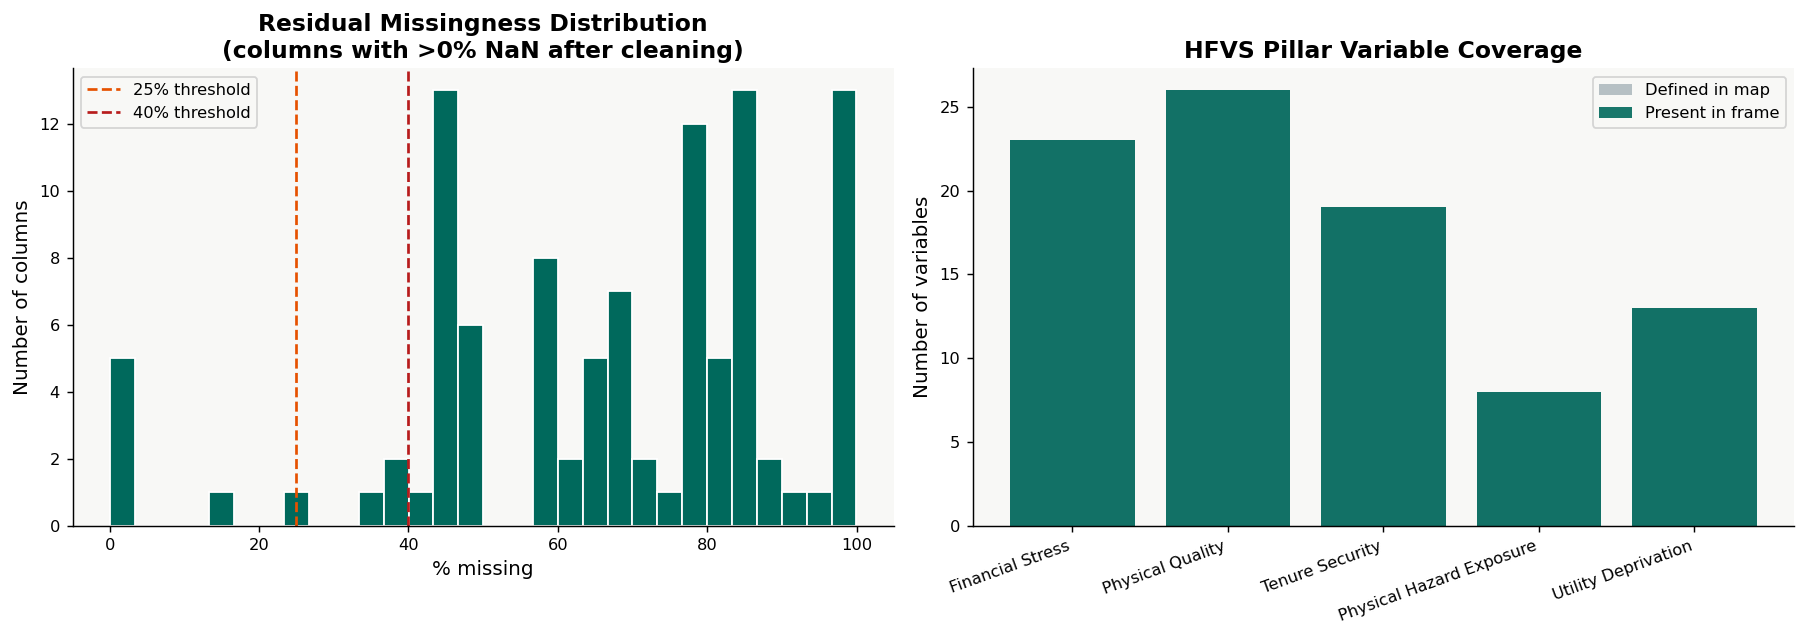

Figure saved.


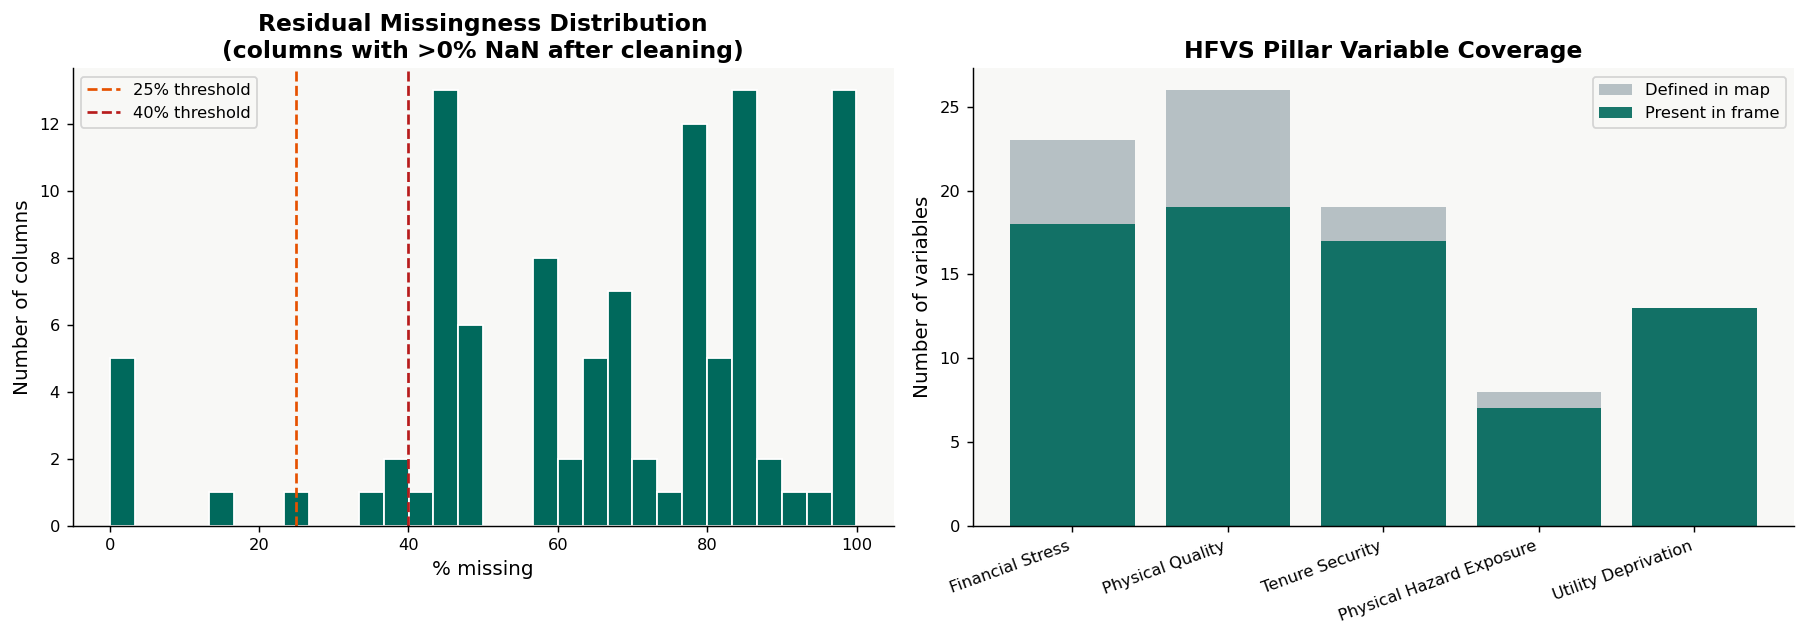

Figure saved.


In [84]:
# ── 13.4  Overview visualisation — post-cleaning missingness ─────────────────
final_miss_plot = final_miss[final_miss > 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: residual missingness distribution
axes[0].hist(final_miss_plot.values, bins=30, color=TEAL, edgecolor='white')
axes[0].axvline(25, color=AMBER, lw=1.5, linestyle='--', label='25% threshold')
axes[0].axvline(40, color=RED,   lw=1.5, linestyle='--', label='40% threshold')
axes[0].set_title('Residual Missingness Distribution\n(columns with >0% NaN after cleaning)')
axes[0].set_xlabel('% missing'); axes[0].set_ylabel('Number of columns')
axes[0].legend()

# Right: pillar coverage
pillar_names  = [p.split('–')[1].strip() for p in PILLAR_MAP]
pillar_present = [sum(1 for c in v if c in df.columns) for v in PILLAR_MAP.values()]
pillar_total   = [len(v) for v in PILLAR_MAP.values()]

x = np.arange(len(pillar_names))
axes[1].bar(x, pillar_total,   color=GRAY,  alpha=0.4, label='Defined in map')
axes[1].bar(x, pillar_present, color=TEAL,  alpha=0.9, label='Present in frame')
axes[1].set_xticks(x); axes[1].set_xticklabels(pillar_names, rotation=20, ha='right')
axes[1].set_title('HFVS Pillar Variable Coverage')
axes[1].set_ylabel('Number of variables')
axes[1].legend()

fig.tight_layout()
fig.savefig(FIGS / '02_postcleaning_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')

---

## Outputs

| File | Location |
|------|----------|
| `master_frame_clean.parquet` | `data/parquet/` |
| `01_sentinel_decoding_log.csv` | `outputs/tables/dsa8301_clean/` |
| `02_full_column_audit.csv` | `outputs/tables/dsa8301_clean/` |
| `03_imputation_log.csv` | `outputs/tables/dsa8301_clean/` |
| `04_winsorise_log.csv` | `outputs/tables/dsa8301_clean/` |
| `05_preprocessing_summary.csv` | `outputs/tables/dsa8301_clean/` |
| `01_missingness_tier_overview.png` | `outputs/figures/dsa8301_clean/` |
| `02_postcleaning_overview.png` | `outputs/figures/dsa8301_clean/` |

**Next step → `DSA8301_Phase3_EDA.ipynb`:** load `master_frame_clean.parquet`,
run normality tests, parametric and nonparametric analyses across the five HFVS pillars.
